# STEP 1: Load your chosen raw dataset using Pandas and perform an initial Exploratory Data Analysis (EDA) to identify missing values, outliers, and data types.

In [80]:
import pandas as pd
import numpy as np

In [124]:
import pandas as pd

df = pd.read_excel("processed_dataset.xlsx")

df.head()

,Feature1,Feature2,Feature3,Feature4,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,Feature11,Feature12,Feature13,Feature14,Feature15,Feature16,Feature17,Feature18,Feature19,Feature20
0,44.0,0.797417,-0.958091,NaN,NaN,158.0,1.490148,5.166124,2.277942,NaN,5,X,1,Category1,Option4,8.824345,11.711130,Yes,Low,NaN
1,47.0,0.026838,-0.244178,D,NaN,NaN,2.151535,0.450312,-3.395356,NaN,3,X,0,Category1,Option2,NaN,13.355832,Yes,Low,cat
2,64.0,0.199990,-1.014799,B,0.0,474.0,1.410613,6.786555,-3.070746,NaN,7,Z,0,Category1,Option2,NaN,13.449484,Yes,Medium,dog
3,67.0,0.474124,0.448040,B,NaN,166.0,0.635091,1.937158,-0.246269,6.004975,20,X,0,Category1,Option2,NaN,7.687652,Yes,Low,cat
4,NaN,0.598516,0.087839,NaN,0.0,NaN,0.392104,4.010937,3.215086,2.891199,3,Z,0,Category1,Option3,11.259371,6.807770,Yes,Low,cat


In [125]:
print("Shape:", df.shape)

Shape: (5000, 20)


In [126]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Feature1     float64
Feature2     float64
Feature3     float64
Feature4      object
Feature5     float64
Feature6     float64
Feature7     float64
Feature8     float64
Feature9     float64
Feature10    float64
Feature11      int64
Feature12     object
Feature13      int64
Feature14     object
Feature15     object
Feature16    float64
Feature17    float64
Feature18     object
Feature19     object
Feature20     object
dtype: object


In [127]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Feature1     2704
Feature2        0
Feature3        0
Feature4     1868
Feature5     2032
Feature6     1984
Feature7        0
Feature8      101
Feature9        0
Feature10    2836
Feature11       0
Feature12       0
Feature13       0
Feature14       0
Feature15       0
Feature16    2006
Feature17       0
Feature18       0
Feature19     295
Feature20    1733
dtype: int64


In [128]:
print("\nCategorical Summary:")
print(df.describe(include='object'))


Categorical Summary:
       Feature4 Feature12  Feature14 Feature15 Feature18 Feature19 Feature20
count      3132      5000       5000      5000      5000      4705      3267
unique        4         3          3         4         2         3         3
top           B         X  Category1   Option2       Yes      High       cat
freq        831      1957       3462      1287      3968      1854      1631


In [129]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(list(numerical_cols))

Numerical Columns:
['Feature1', 'Feature2', 'Feature3', 'Feature5', 'Feature6', 'Feature7', 'Feature8', 'Feature9', 'Feature10', 'Feature11', 'Feature13', 'Feature16', 'Feature17']


In [130]:
print("\nCategorical Columns:")
print(list(categorical_cols))


Categorical Columns:
['Feature4', 'Feature12', 'Feature14', 'Feature15', 'Feature18', 'Feature19', 'Feature20']


# DETECT OUTLIERS

In [132]:
for col in numerical_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {outliers} outliers")

Feature1: 0 outliers
Feature2: 0 outliers
Feature3: 40 outliers
Feature5: 308 outliers
Feature6: 0 outliers
Feature7: 237 outliers
Feature8: 149 outliers
Feature9: 107 outliers
Feature10: 28 outliers
Feature11: 212 outliers
Feature13: 0 outliers
Feature16: 26 outliers
Feature17: 0 outliers


# STEP 2: Handle Missing Values by applying mean/median imputation for numerical features and mode imputation for categorical features.

In [134]:
# Numerical columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [135]:
print(df.isnull().sum())

Feature1     0
Feature2     0
Feature3     0
Feature4     0
Feature5     0
Feature6     0
Feature7     0
Feature8     0
Feature9     0
Feature10    0
Feature11    0
Feature12    0
Feature13    0
Feature14    0
Feature15    0
Feature16    0
Feature17    0
Feature18    0
Feature19    0
Feature20    0
dtype: int64


# MINI TASK 1 : Categorical Encoding Implementation

In [136]:
# STEP 3: Encode categorical variables by applying One-Hot Encoding for nominal data and Label/Ordinal Encoding for ordinal data.

In [137]:
# ONE-HOT ENCODING
for col in categorical_cols:
    print("\n", col)
    print(df[col].unique())


 Feature4
['B' 'D' 'A' 'C']

 Feature12
['X' 'Z' 'Y']

 Feature14
['Category1' 'Category3' 'Category2']

 Feature15
['Option4' 'Option2' 'Option3' 'Option1']

 Feature18
['Yes' 'No']

 Feature19
['Low' 'Medium' 'High']

 Feature20
['cat' 'dog' 'some other']


In [138]:
cols_to_encode = ["Feature4", "Feature12", "Feature14", "Feature15", "Feature20"]

existing_cols = [col for col in cols_to_encode if col in df.columns]

df = pd.get_dummies(
    df,
    columns=existing_cols,
    drop_first=True                # TO AVOID DUMMY TRAPS
)

In [139]:
print(df.head())

   Feature1  Feature2  Feature3  Feature5  Feature6  Feature7  Feature8  \
0      44.0  0.797417 -0.958091       0.0  158.0000  1.490148  5.166124   
1      47.0  0.026838 -0.244178       0.0  507.6797  2.151535  0.450312   
2      64.0  0.199990 -1.014799       0.0  474.0000  1.410613  6.786555   
3      67.0  0.474124  0.448040       0.0  166.0000  0.635091  1.937158   
4      47.0  0.598516  0.087839       0.0  507.6797  0.392104  4.010937   

   Feature9  Feature10  Feature11  ...  Feature4_D  Feature12_Y  Feature12_Z  \
0  2.277942   4.936186          5  ...       False        False        False   
1 -3.395356   4.936186          3  ...        True        False        False   
2 -3.070746   4.936186          7  ...       False        False         True   
3 -0.246269   6.004975         20  ...       False        False        False   
4  3.215086   2.891199          3  ...       False        False         True   

  Feature14_Category2 Feature14_Category3  Feature15_Option2  \
0   

In [140]:
# LABEL ENCODING
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Feature18"] = le.fit_transform(df["Feature18"])

In [141]:
print(df["Feature18"])

0       1
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    1
4998    0
4999    1
Name: Feature18, Length: 5000, dtype: int64


# MINI TASK 2

# STEP 4: Scale numerical features using MinMaxScaler/ StandardScaler

In [175]:
import numpy as np

numerical_cols = df.select_dtypes(
    include=['int64','float64']
).columns

print(numerical_cols)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature5', 'Feature6', 'Feature7',
       'Feature8', 'Feature9', 'Feature10', 'Feature11', 'Feature13',
       'Feature16', 'Feature17', 'Feature18', 'Feature1_Feature2_Interaction'],
      dtype='object')


# ORIGINAL DISTRIBUTIONS

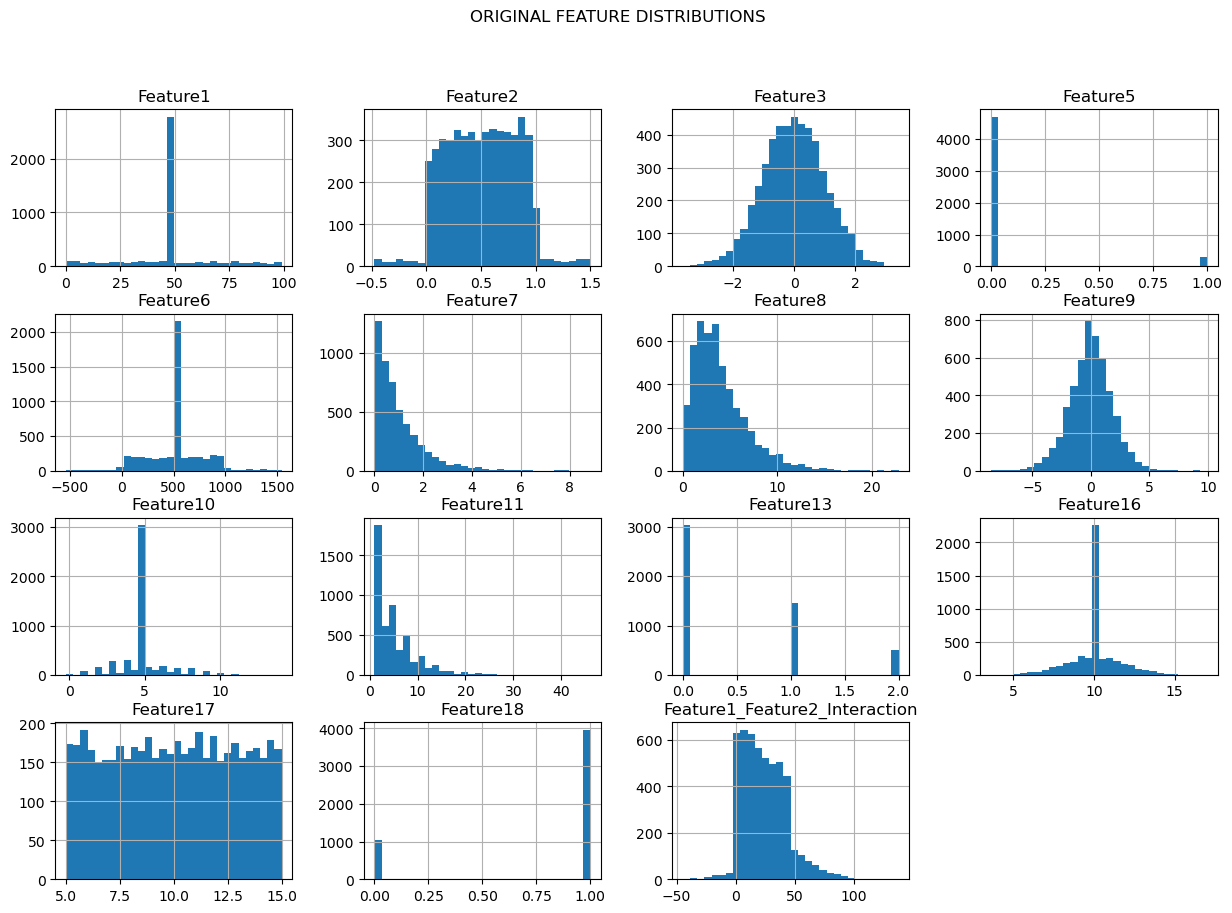

In [176]:
import matplotlib.pyplot as plt

df[numerical_cols].hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("ORIGINAL FEATURE DISTRIBUTIONS")
plt.show()

# 1. Standard Scaler

In [177]:
from sklearn.model_selection import train_test_split

X = df.drop("Feature13", axis=1)   # Example target
y = df["Feature13"]

In [178]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [180]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()

standard_scaled = standard_scaler.fit_transform(
    df[numerical_cols]
)

standard_scaled_df = pd.DataFrame(
    standard_scaled,
    columns=numerical_cols
)
print("Standard SCALING COMPLETED SUCCESSFULLY!")

Standard SCALING COMPLETED SUCCESSFULLY!


# Plot after standard scaling

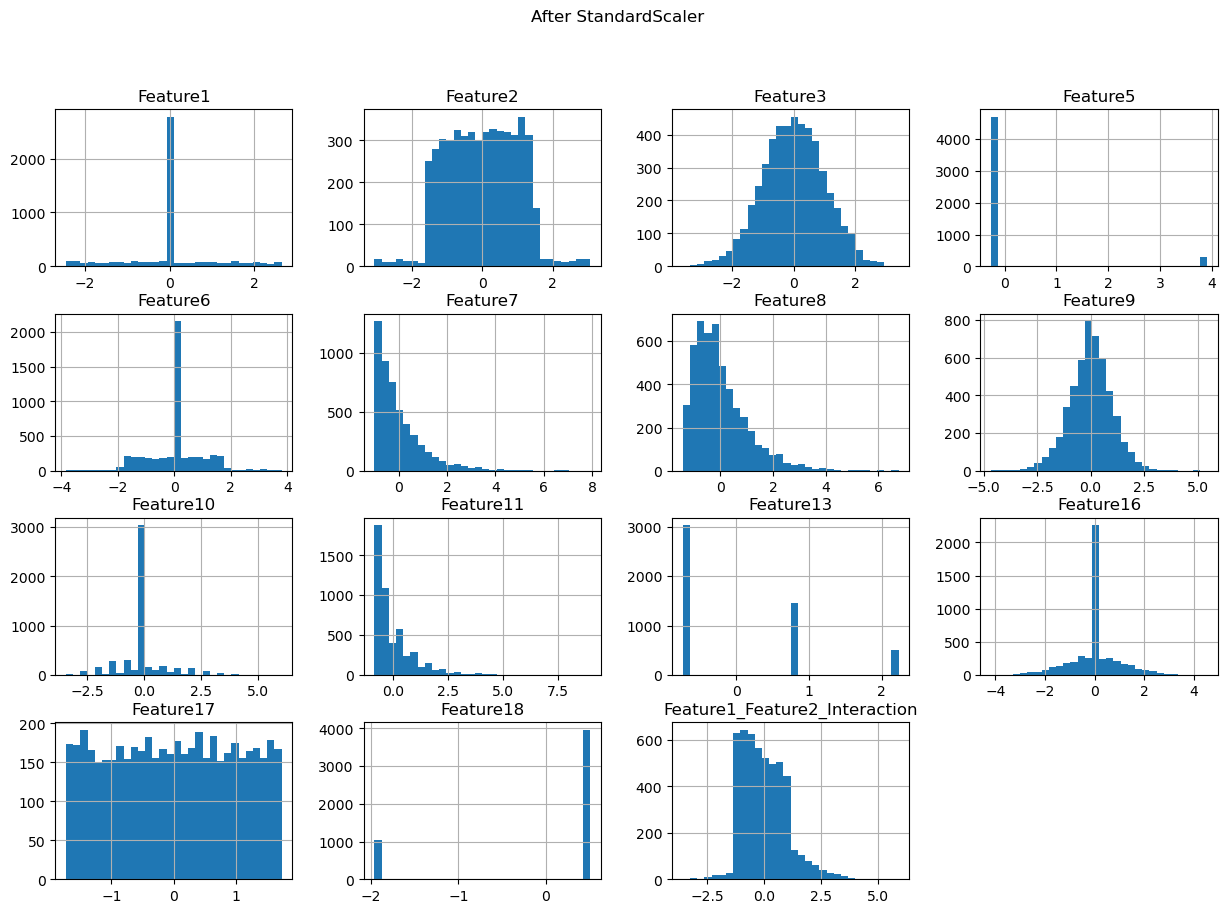

In [181]:
standard_scaled_df.hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("After StandardScaler")
plt.show()

# Before vs After

In [182]:
print("Original Statistics")
print(df[numerical_cols].describe())

print("\nAfter StandardScaler")
print(standard_scaled_df.describe())

Original Statistics
          Feature1     Feature2     Feature3     Feature5     Feature6  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean     47.506400     0.509843    -0.009058     0.061600   507.090764   
std      19.389893     0.322480     1.010739     0.240452   272.732462   
min       0.000000    -0.476438    -3.644316     0.000000  -538.762910   
25%      47.000000     0.253741    -0.686737     0.000000   418.000000   
50%      47.000000     0.513507    -0.017156     0.000000   507.679700   
75%      47.000000     0.770195     0.688604     0.000000   610.000000   
max      99.000000     1.497998     3.422062     1.000000  1543.622087   

          Feature7     Feature8     Feature9    Feature10    Feature11  \
count  5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean      0.993603     3.983471    -0.024540     4.963020     4.967800   
std       0.991321     2.784779     1.829975     1.506217     4.571624   
min       0.00077

# 2. MinMaxScaler

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

minmax_scaled = minmax_scaler.fit_transform(
    df[numerical_cols]
)

minmax_scaled_df = pd.DataFrame(
    minmax_scaled,
    columns=numerical_cols
)
print("MinMax SCALING COMPLETED SUCCESSFULLY!")

# Plot after MinMax Scaling

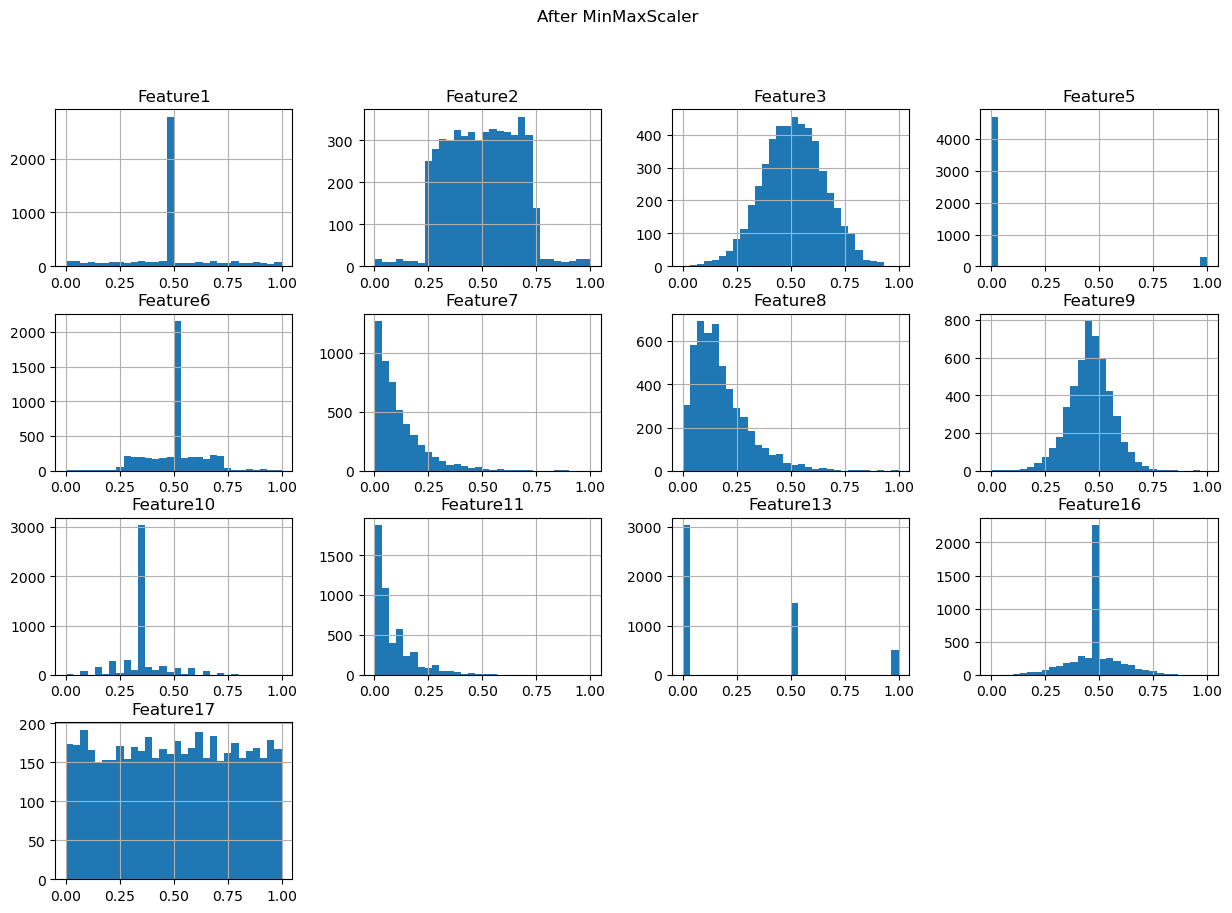

In [183]:
minmax_scaled_df.hist(
    figsize=(15,10),
    bins=30
)

plt.suptitle("After MinMaxScaler")
plt.show()

# Before vs After

In [184]:
print("Minimum Values")
print(minmax_scaled_df.min())

print("\nMaximum Values")
print(minmax_scaled_df.max())

Minimum Values
Feature1     0.0
Feature2     0.0
Feature3     0.0
Feature5     0.0
Feature6     0.0
Feature7     0.0
Feature8     0.0
Feature9     0.0
Feature10    0.0
Feature11    0.0
Feature13    0.0
Feature16    0.0
Feature17    0.0
dtype: float64

Maximum Values
Feature1     1.0
Feature2     1.0
Feature3     1.0
Feature5     1.0
Feature6     1.0
Feature7     1.0
Feature8     1.0
Feature9     1.0
Feature10    1.0
Feature11    1.0
Feature13    1.0
Feature16    1.0
Feature17    1.0
dtype: float64


# STEP 5: Feature Engineering - Create at least one new feature.

In [150]:
df["Feature1_Feature2_Interaction"] = (
    df["Feature1"] * df["Feature2"]
)

In [151]:
print(df.columns)

Index(['Feature1', 'Feature2', 'Feature3', 'Feature5', 'Feature6', 'Feature7',
       'Feature8', 'Feature9', 'Feature10', 'Feature11', 'Feature13',
       'Feature16', 'Feature17', 'Feature18', 'Feature19', 'Feature4_B',
       'Feature4_C', 'Feature4_D', 'Feature12_Y', 'Feature12_Z',
       'Feature14_Category2', 'Feature14_Category3', 'Feature15_Option2',
       'Feature15_Option3', 'Feature15_Option4', 'Feature20_dog',
       'Feature20_some other', 'Feature1_Feature2_Interaction'],
      dtype='object')


# STEP 6: Final Train-Test Split Without Data Leakage

In [168]:
from sklearn.preprocessing import StandardScaler

y = df["Feature13"]
X = df.drop("Feature13", axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
scaler = StandardScaler()

num_cols = X_train.select_dtypes(
    include=['int64','float64']
).columns

X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [169]:
print("Training Shape:", X_train.shape)

Training Shape: (4000, 27)


In [170]:
print("Testing Shape:", X_test.shape)

Testing Shape: (1000, 27)


In [185]:
df.head()

,Feature1,Feature2,Feature3,Feature5,Feature6,Feature7,Feature8,Feature9,Feature10,Feature11,...,Feature12_Y,Feature12_Z,Feature14_Category2,Feature14_Category3,Feature15_Option2,Feature15_Option3,Feature15_Option4,Feature20_dog,Feature20_some other,Feature1_Feature2_Interaction
0,44.0,0.797417,-0.958091,0.0,158.0000,1.490148,5.166124,2.277942,4.936186,5,...,False,False,False,False,False,False,True,False,False,35.086346
1,47.0,0.026838,-0.244178,0.0,507.6797,2.151535,0.450312,-3.395356,4.936186,3,...,False,False,False,False,True,False,False,False,False,1.261394
2,64.0,0.199990,-1.014799,0.0,474.0000,1.410613,6.786555,-3.070746,4.936186,7,...,False,True,False,False,True,False,False,True,False,12.799360
3,67.0,0.474124,0.448040,0.0,166.0000,0.635091,1.937158,-0.246269,6.004975,20,...,False,False,False,False,True,False,False,False,False,31.766341
4,47.0,0.598516,0.087839,0.0,507.6797,0.392104,4.010937,3.215086,2.891199,3,...,False,True,False,False,False,True,False,False,False,28.130273


In [186]:
df.to_excel("processed_dataset_final.xlsx", index=False)